<a href="https://colab.research.google.com/github/Ebrahim-khewani/Test/blob/calssfication-model/classfication_ai_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import files
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/samsung_or_iphone/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    '/content/drive/MyDrive/samsung_or_iphone/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 6 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

In [8]:
EPOCHS = 10
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 0.6649
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step - accuracy: 0.5000 - loss: 0.6649 - val_accuracy: 0.5000 - val_loss: 0.9069
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.9069 - val_accuracy: 0.8333 - val_loss: 0.5954
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step - accuracy: 0.8333 - loss: 0.5954 - val_accuracy: 0.8333 - val_loss: 0.5908
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8333 - loss: 0.5908 - val_accuracy: 0.8333 - val_loss: 0.5356
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.8333 - loss: 0.5356 - val_accuracy: 1.0000 - val_loss: 0.4629
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 1.0000 - loss: 0.4629 - val_accuracy: 1.0000 - val_loss: 0.3402
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 1.0000 - loss: 0.3402 - val_accuracy: 0.8333 - val_loss: 0.2372
E

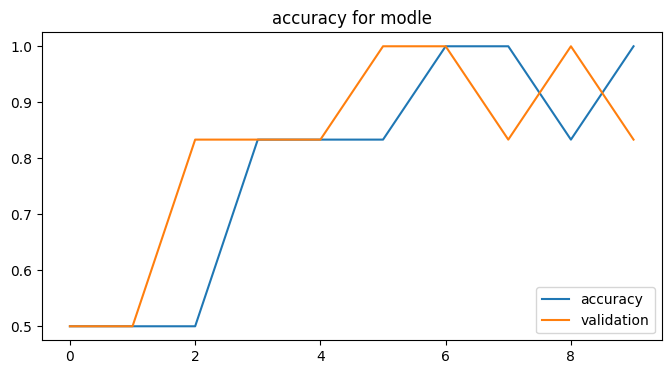

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(EPOCHS)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label='accuracy')
plt.plot(epochs_range, val_acc, label='validation')
plt.legend(loc='lower right')
plt.title('accuracy for modle')
plt.show()


In [10]:
from tensorflow.keras.preprocessing import image

In [11]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    if prediction[0] > 0.5:
        print("samsung")
    else:
        print("iphone")

In [12]:
predict_image('/content/sample_data/test/s.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
samsung
